In [3]:
# Step 1: Import necessary libraries
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import datasets, layers, models


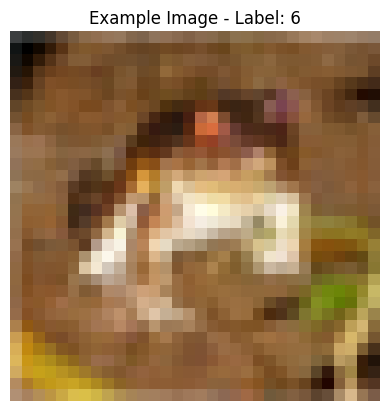

In [4]:
# Step 2: Load a sample image from CIFAR10 (tiny 32x32 colored images)
(train_images, train_labels), (test_images, test_labels) = datasets.cifar10.load_data()
train_images, test_images = train_images / 255.0, test_images / 255.0  # normalize

# Show one sample image
plt.imshow(train_images[0])
plt.title(f"Example Image - Label: {train_labels[0][0]}")
plt.axis("off")
plt.show()


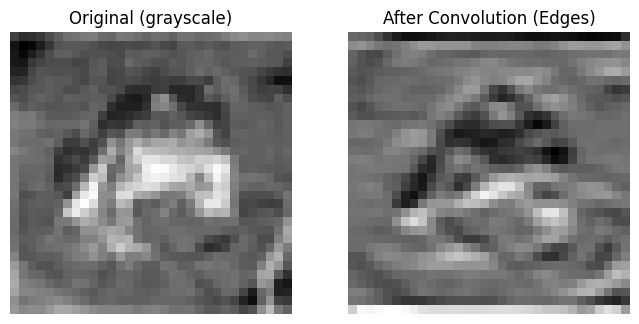

In [5]:
# Step 3: Define a simple 3x3 edge-detection filter
edge_filter = np.array([[-1, -1, -1],
                        [ 0,  0,  0],
                        [ 1,  1,  1]])

# Take one grayscale channel from the image
gray = np.mean(train_images[0], axis=2)

# Apply convolution manually
from scipy.signal import convolve2d
edge_detected = convolve2d(gray, edge_filter, mode='same', boundary='fill', fillvalue=0)

# Plot original vs edge-detected
plt.figure(figsize=(8,4))
plt.subplot(1,2,1)
plt.imshow(gray, cmap='gray'); plt.title("Original (grayscale)")
plt.axis('off')
plt.subplot(1,2,2)
plt.imshow(edge_detected, cmap='gray'); plt.title("After Convolution (Edges)")
plt.axis('off')
plt.show()


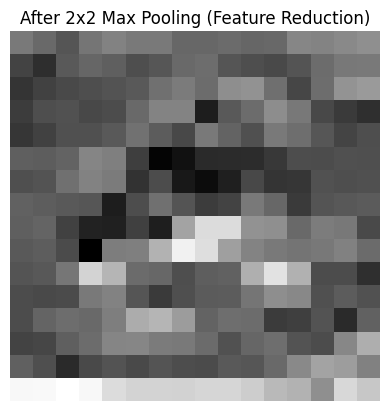

In [6]:
# Step 4: Max Pooling demonstration (2x2 blocks)
def max_pool(image, size=2):
    h, w = image.shape
    pooled = image.reshape(h//size, size, w//size, size).max(axis=(1,3))
    return pooled

pooled_image = max_pool(edge_detected)
plt.imshow(pooled_image, cmap='gray')
plt.title("After 2x2 Max Pooling (Feature Reduction)")
plt.axis('off')
plt.show()


In [7]:
# Step 5: Build a CNN using Keras
model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),  # detects edges & patterns
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation='relu'),  # deeper: shapes/textures
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation='relu'),  # even deeper: object parts
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10)  # 10 classes in CIFAR10
])

model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 122,570 (478.79 KB)

 Trainable params: 122,570 (478.79 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
# Step 6: Compile and train the CNN briefly
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

history = model.fit(train_images[:5000], train_labels[:5000], epochs=3,
                    validation_data=(test_images[:1000], test_labels[:1000]))


Epoch 1/3
157/157 ━━━━━━━━━━━━━━━━━━━━ 9s 42ms/step - accuracy: 0.1802 - loss: 2.1828 - val_accuracy: 0.2780 - val_loss: 1.9670
Epoch 2/3
157/157 ━━━━━━━━━━━━━━━━━━━━ 7s 47ms/step - accuracy: 0.3304 - loss: 1.8130 - val_accuracy: 0.4020 - val_loss: 1.6479
Epoch 3/3
157/157 ━━━━━━━━━━━━━━━━━━━━ 6s 36ms/step - accuracy: 0.3887 - loss: 1.6484 - val_accuracy: 0.4440 - val_loss: 1.5680


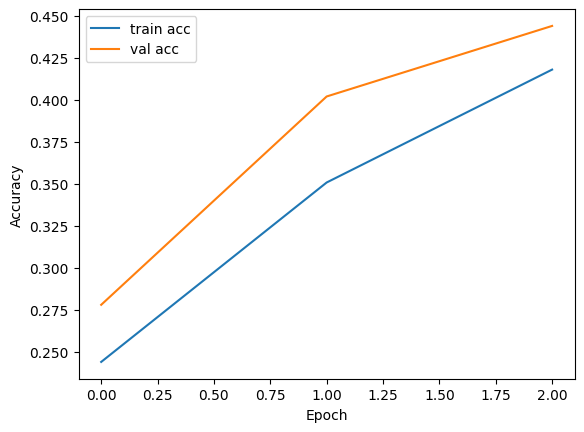

In [9]:
# Step 7: Plot accuracy and loss over epochs
plt.plot(history.history['accuracy'], label='train acc')
plt.plot(history.history['val_accuracy'], label='val acc')
plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.legend(); plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step


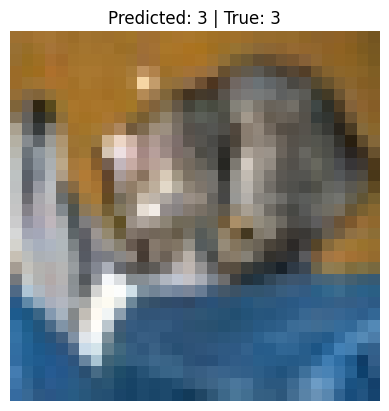

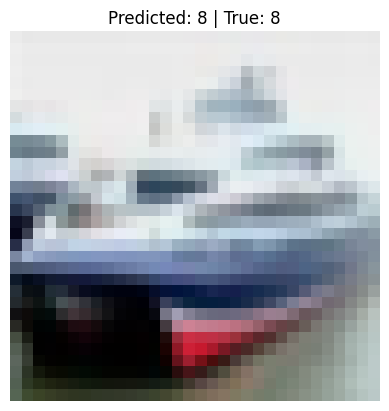

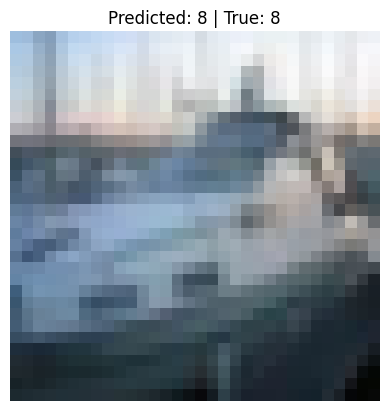

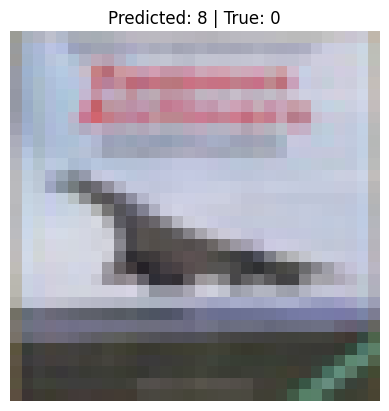

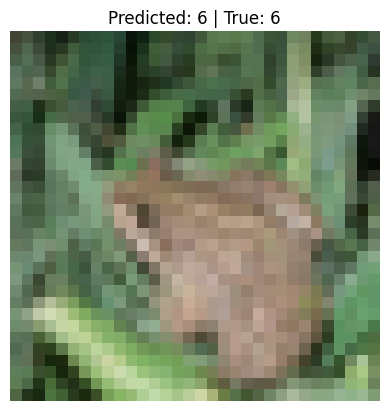

In [10]:
# Step 8: Show predictions on test images
prob_model = tf.keras.Sequential([model, layers.Softmax()])
predictions = prob_model.predict(test_images[:5])

for i in range(5):
    plt.imshow(test_images[i])
    plt.title(f"Predicted: {np.argmax(predictions[i])} | True: {test_labels[i][0]}")
    plt.axis('off')
    plt.show()
